# <center> <font color="#0036a3">Maestría en Inteligencia Artificial Aplicada (MNA)</font> </center>

<center>

[![Institución](https://img.shields.io/badge/INSTITUCIÓN-TECNOLÓGICO_DE_MONTERREY-0036a3?style=for-the-badge)](https://tec.mx)
[![Programa](https://img.shields.io/badge/PROGRAMA-MNA-0036a3?style=for-the-badge)](https://tec.mx)
[![Materia](https://img.shields.io/badge/MATERIA-PROYECTO_INTEGRADOR-E0A800?style=for-the-badge&logoColor=white)](https://tec.mx)

</center>

<center>

[![Python](https://img.shields.io/badge/Python-3776AB?style=flat-square&logo=python&logoColor=white)](https://www.python.org/)
[![Jupyter](https://img.shields.io/badge/Jupyter-F37626?style=flat-square&logo=jupyter&logoColor=white)](https://jupyter.org/)
[![NumPy](https://img.shields.io/badge/NumPy-013243?style=flat-square&logo=numpy&logoColor=white)](https://numpy.org/)
[![OpenCV](https://img.shields.io/badge/OpenCV-5C3EE8?style=flat-square&logo=opencv&logoColor=white)](https://opencv.org/)
[![GitHub](https://img.shields.io/badge/Repo-GitHub-181717?style=flat-square&logo=github&logoColor=white)](https://github.com/jmtoral/proyecto_integrador_52)

</center>

---

## **<font color="#0036a3">Semana 3: Avance 1 — Análisis Exploratorio de Datos (EDA)</font>**

### **<font color="#E0A800">Proyecto Integrador — TC5035.10</font>**
**Materia:** Proyecto Integrador — TC5035.10

> **Título:** La luz que opaca: Detección y supresión de reflejos especulares en imágenes endoscópicas.

---

### **Equipo Docente**
* **Dra. Grettel Barceló Alonso** | Profesora Titular
* **Dr. Luis Eduardo Falcón Morales** | Profesor Titular
* **Mtra. Verónica Sandra Guzmán de Valle** | Profesora Asistente

**Patrocinador:** Dr. Gerardo Camacho

---

## **<center> <font color="#0036a3">Equipo 52</font> </center>**

<table style="width:100%; border:none; border-collapse:collapse;">
  <tr>
    <td align="center" style="border:none; width:33%; padding:10px;">
      <img src="https://raw.githubusercontent.com/jmtoral/proyecto_integrador_52/main/reports/elda.jpg" width="160px" height="160px" style="border-radius:50%; object-fit:cover;">
      <br>
      <h4>Elda Cristina Morales Sánchez de la Barquera</h4>
      <code>A00449074</code><br>
      <small>MNA Student</small>
    </td>
    <td align="center" style="border:none; width:33%; padding:10px;">
      <img src="https://raw.githubusercontent.com/jmtoral/proyecto_integrador_52/main/reports/mpgc.jpg" width="160px" height="160px" style="border-radius:50%; object-fit:cover;">
      <br>
      <h4>María Paula Gutiérrez Cervantes</h4>
      <code>A01747706</code><br>
      <small>MNA Student</small>
    </td>
    <td align="center" style="border:none; width:33%; padding:10px;">
      <img src="https://raw.githubusercontent.com/jmtoral/proyecto_integrador_52/main/reports/jmtc.jpg" width="160px" height="160px" style="border-radius:50%; object-fit:cover;">
      <br>
      <h4>José Manuel Toral Cruz</h4>
      <code>A01122243</code><br>
      <small>MNA Student</small>
    </td>
  </tr>
</table>

---

### **<font color="#E0A800">Información de Entrega</font>**
* **Actividad:** Avance 1. Análisis exploratorio de datos.
* **Fecha Límite:** 11 de mayo de 2026
* **Framework de Calidad:** CRISP-ML(Q)
* **Objetivos Clave:**
    * **EDA de Iluminación:** Cuantificación del gradiente radial no uniforme en imágenes endoscópicas.
    * **Métricas:** CV de luminancia, ratio centro/borde, detección de especulares, correlación luminancia–GT.

---

## EDA 01 — Iluminación no uniforme en endoscopía

**¿Qué estudia este notebook?**

El endoscopio lleva su propia fuente de luz coaxial al lente. Esto produce un patrón de iluminación muy específico: **más brillante en el centro, más oscuro hacia los bordes**. Ese gradiente no es información del tejido — es un artefacto óptico del instrumento.

El problema para los modelos de profundidad (NeXF, EndoGaussian, EndoDepthAndMotion) es que:
1. Interpretan brillo como textura o reflectancia del tejido.
2. Un píxel más brillante en el centro puede parecer "diferente" al mismo tejido en el borde aunque sea idéntico.
3. Los reflejos especulares (manchas blancas saturadas) no tienen información de profundidad: son puntos donde el structured light no pudo medir.

**Objetivo de este notebook:** cuantificar con números ese gradiente para poder argumentar que corregirlo mejora los modelos.

---

### Estructura
1. Configuración e imports
2. Perfil radial de luminancia — la forma del gradiente
3. Mapa 2D del gradiente — dónde está el problema espacialmente
4. Especulares — cuántos píxeles están saturados y dónde
5. Correlación luminancia–validez del GT — ¿el brillo predice dónde falla el depth?
6. Índice de no-uniformidad por keyframe — una métrica resumen
7. Resumen ejecutivo

---
## Sección 1 — Configuración e imports

In [21]:
import zipfile, io
import numpy as np
import cv2
import tifffile
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path
from scipy.ndimage import gaussian_filter

# ── Cambia esta ruta si tus ZIPs están en otro lugar ──────────────────────────
SCARED_DIR = Path("E:/scared_raw")
# ─────────────────────────────────────────────────────────────────────────────

OUT_DIR = Path("../outcomes/eda_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = SCARED_DIR / "dataset_1.zip"
DATASET  = "dataset_1"
KF_NAMES = ["keyframe_1", "keyframe_2", "keyframe_3", "keyframe_4", "keyframe_5"]

assert ZIP_PATH.exists(), f"No encuentro: {ZIP_PATH}"
print("ZIP encontrado:", ZIP_PATH)
print("Keyframes a analizar:", KF_NAMES)

ZIP encontrado: E:\scared_raw\dataset_1.zip
Keyframes a analizar: ['keyframe_1', 'keyframe_2', 'keyframe_3', 'keyframe_4', 'keyframe_5']


### Funciones de lectura
Las mismas que en `00_exploracion_scared.ipynb` — leen PNG y TIFF directamente del ZIP sin extraer al disco.

**¿Qué es `depth coverage`?**

El TIFF de profundidad almacena coordenadas XYZ en milímetros para cada píxel. Pero hay píxeles donde el sensor de luz estructurada *no pudo medir* — por ejemplo, donde hay un reflejo especular (mancha blanca) o una curvatura tan extrema que el haz de luz no rebotó correctamente. En esos píxeles, el TIFF guarda el valor `(0, 0, 0)` — no un cero de profundidad real, sino una señal de "sin dato".

La función `read_depth` detecta esos ceros con `z[z <= 0] = np.nan` y los convierte a `NaN` (Not a Number), que es la forma estándar de Python/NumPy para representar "aquí no hay información".

`depth coverage` es el porcentaje de píxeles que **sí tienen dato válido** — es decir, que no son NaN:

```
coverage = píxeles con Z > 0 / total de píxeles × 100
```

Si el coverage es 78%, significa que el 22% restante no tiene ground truth de profundidad. Esos píxeles se excluyen automáticamente al entrenar o evaluar un modelo, porque no hay valor correcto contra el que comparar.

In [22]:
def read_image(zf, dataset, kf):
    buf = np.frombuffer(zf.read(f"{dataset}/{kf}/Left_Image.png"), np.uint8)
    return cv2.cvtColor(cv2.imdecode(buf, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

def read_depth(zf, dataset, kf):
    with zf.open(f"{dataset}/{kf}/left_depth_map.tiff") as f:
        raw = tifffile.imread(io.BytesIO(f.read()))
    z = raw[..., 2].astype(np.float32)
    z[z <= 0] = np.nan
    return z

def luminance(img_rgb):
    """Luminancia perceptual (ITU-R BT.601): Y = 0.299R + 0.587G + 0.114B"""
    return (0.299 * img_rgb[..., 0] +
            0.587 * img_rgb[..., 1] +
            0.114 * img_rgb[..., 2]).astype(np.float32)

# Cargar los 5 keyframes en memoria
images, depths, lums = {}, {}, {}

with zipfile.ZipFile(ZIP_PATH) as zf:
    for kf in KF_NAMES:
        images[kf] = read_image(zf, DATASET, kf)
        depths[kf] = read_depth(zf, DATASET, kf)
        lums[kf]   = luminance(images[kf])
        print(f"{kf}: img {images[kf].shape}  depth coverage {(~np.isnan(depths[kf])).mean()*100:.1f}%")

keyframe_1: img (1024, 1280, 3)  depth coverage 78.4%
keyframe_2: img (1024, 1280, 3)  depth coverage 83.0%
keyframe_3: img (1024, 1280, 3)  depth coverage 86.8%
keyframe_4: img (1024, 1280, 3)  depth coverage 73.0%
keyframe_5: img (1024, 1280, 3)  depth coverage 71.9%


---
## Sección 2 — Perfil radial de luminancia

### ¿Qué es un perfil radial?

Para cada píxel de la imagen calculamos su **distancia al centro** (en píxeles). Luego promediamos la luminancia de todos los píxeles que están a la misma distancia. El resultado es una curva: eje X = distancia al centro, eje Y = luminancia promedio.

**Cómo interpretar la curva:**
- Si la curva **baja de izquierda a derecha** → el centro es más brillante que los bordes. Eso es el gradiente radial del endoscopio.
- Si la curva es **plana** → la iluminación es uniforme (lo que queremos lograr después de la corrección).
- La **pendiente** de la bajada es la severidad del problema: una caída de 50+ puntos entre centro y borde es severa.

**Por qué importa para los modelos:** si el modelo ve que el centro siempre es brillante, puede aprender esa correlación espuria en lugar de aprender la reflectancia real del tejido. Al corregir el gradiente, el modelo recibe una señal más limpia.

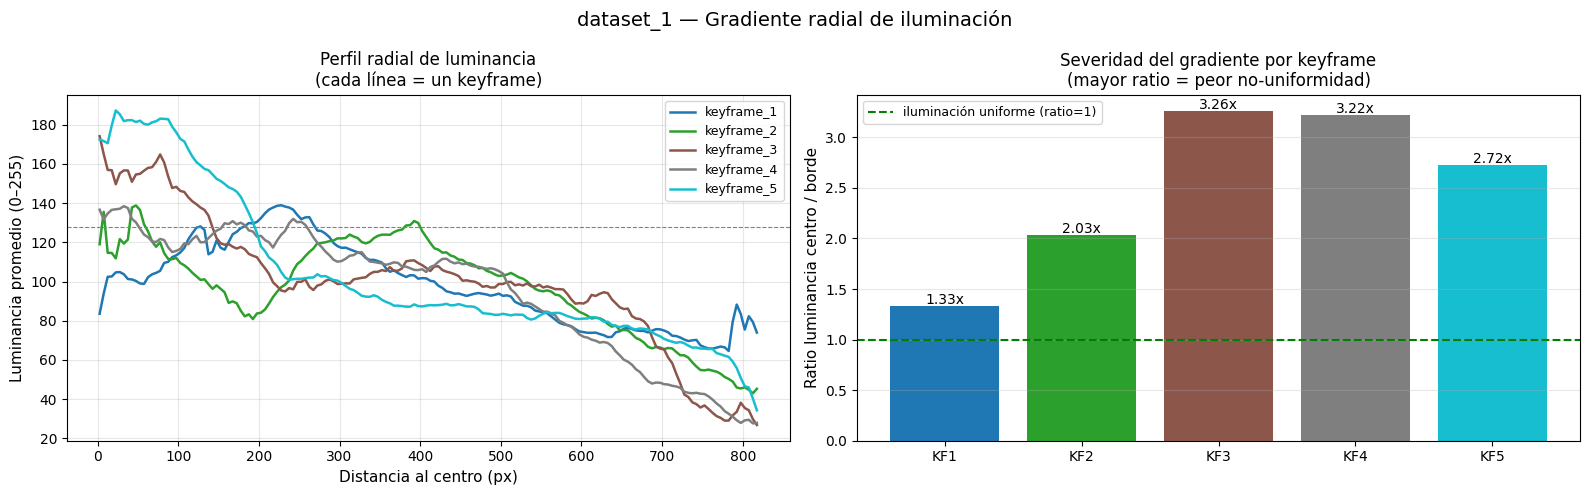


Ratio centro/borde por keyframe (1.0 = uniforme, >1.5 = severo):
  keyframe_1: 1.332x  [MODERADO]
  keyframe_2: 2.033x  [SEVERO]
  keyframe_3: 3.258x  [SEVERO]
  keyframe_4: 3.221x  [SEVERO]
  keyframe_5: 2.723x  [SEVERO]


In [23]:
H, W = images["keyframe_1"].shape[:2]   # 1024 x 1280
cy, cx = H // 2, W // 2

# Mapa de distancias al centro (en píxeles)
yy, xx = np.mgrid[0:H, 0:W]
dist_map = np.sqrt((yy - cy)**2 + (xx - cx)**2).astype(np.float32)
max_dist = dist_map.max()

# Bins de distancia (cada bin = ~5 px)
bin_edges = np.arange(0, max_dist + 5, 5)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(KF_NAMES)))

ratios = {}   # centro/borde ratio por keyframe

for kf, color in zip(KF_NAMES, colors):
    lum = lums[kf]
    profile = []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (dist_map >= lo) & (dist_map < hi)
        profile.append(lum[mask].mean() if mask.any() else np.nan)
    profile = np.array(profile)

    # ratio centro / borde (últimos 10% de radio)
    center_val = profile[:5].mean()           # primeros 25 px
    border_val = profile[-len(profile)//5:].mean()  # último 20%
    ratios[kf] = center_val / border_val

    axes[0].plot(bin_centers, profile, color=color, label=kf, lw=1.8)

axes[0].set_xlabel("Distancia al centro (px)", fontsize=11)
axes[0].set_ylabel("Luminancia promedio (0–255)", fontsize=11)
axes[0].set_title("Perfil radial de luminancia\n(cada línea = un keyframe)", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].axhline(128, color='gray', lw=0.8, ls='--', label='neutro')
axes[0].grid(True, alpha=0.3)

# Ratio centro/borde como barras
kf_labels = [k.replace("keyframe_", "KF") for k in KF_NAMES]
ratio_vals = [ratios[k] for k in KF_NAMES]
bars = axes[1].bar(kf_labels, ratio_vals, color=[c for c in colors])
axes[1].axhline(1.0, color='green', lw=1.5, ls='--', label='iluminación uniforme (ratio=1)')
axes[1].set_ylabel("Ratio luminancia centro / borde", fontsize=11)
axes[1].set_title("Severidad del gradiente por keyframe\n(mayor ratio = peor no-uniformidad)", fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, ratio_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f"{val:.2f}x", ha='center', fontsize=10)

plt.suptitle("dataset_1 — Gradiente radial de iluminación", fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR / "16_perfil_radial.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nRatio centro/borde por keyframe (1.0 = uniforme, >1.5 = severo):")
for kf, r in ratios.items():
    severity = "SEVERO" if r > 1.5 else ("MODERADO" if r > 1.2 else "LEVE")
    print(f"  {kf}: {r:.3f}x  [{severity}]")

### Cómo leer estos resultados

**Gráfica izquierda (perfiles):**
- El eje X va desde el centro (0 px) hasta la esquina (≈800 px).
- Una curva que cae indica que el centro es más brillante que el borde.
- Si todas las líneas tienen la misma forma, el problema es sistemático del instrumento (no depende del tejido).

**Gráfica derecha (ratio):**
- `ratio = luminancia_centro / luminancia_borde`
- `1.0` = iluminación perfectamente uniforme.
- `1.5x` significa que el centro es 50% más brillante que el borde — eso es suficiente para confundir un modelo.
- `2.0x` significa el doble de brillo en el centro: definitivamente problemático.

**Qué escribir en el reporte:** el ratio promedio justifica por qué se necesita corrección. Si es > 1.3 en todos los keyframes, el gradiente es sistemático y reproducible.

---
## Sección 3 — Mapa 2D del gradiente de iluminación

### ¿Qué es el mapa del gradiente?

El perfil radial nos da la forma promedio. Pero el gradiente real no es perfectamente simétrico — el centro óptico de la cámara no está exactamente en el centro geométrico (lo vimos en la calibración: cx=597, cy=520 en lugar de 640, 512).

El **mapa 2D** muestra el gradiente sin asumir simetría: es un promedio de los 5 keyframes suavizado con un filtro gaussiano. Las zonas amarillas son las más brillantes, las azules las más oscuras.

**Cómo interpretarlo:**
- Si el manchón brillante está desplazado del centro geométrico → el lente está descentrado (consistente con cx≠W/2).
- La forma del manchón (circular vs. elíptica) revela la simetría del sistema óptico.
- Este mapa es la base del **modelo de corrección**: si estimamos este mapa, podemos dividir cada imagen por él para normalizarlo.

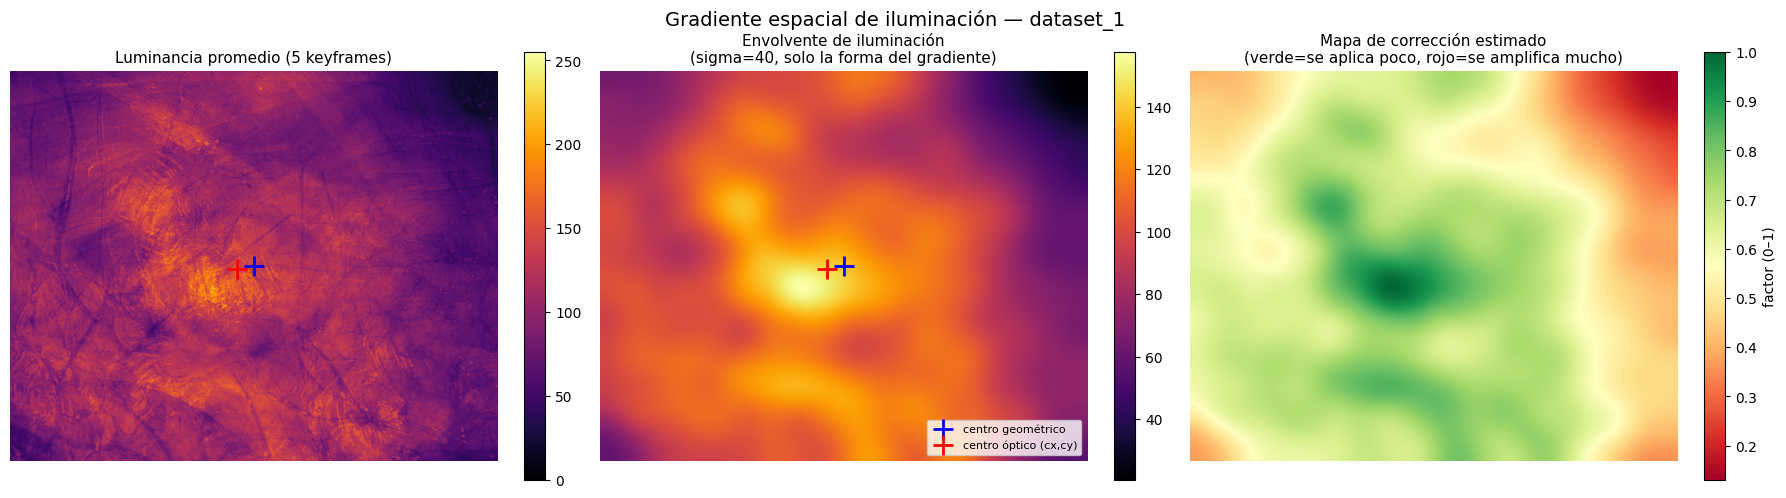

Luminancia mínima en la envolvente: 20.6
Luminancia máxima en la envolvente: 157.5
Factor de amplificación máximo en bordes: 7.64x
  → para igualar el borde al centro, hay que multiplicar el borde por ese factor


In [24]:
# Promedio de luminancias entre keyframes (el "fondo" de iluminación promedio)
lum_stack = np.stack([lums[kf] for kf in KF_NAMES], axis=0)
lum_mean  = lum_stack.mean(axis=0)           # promedio entre keyframes
lum_smooth = gaussian_filter(lum_mean, sigma=40)   # suavizado fuerte → solo la envolvente

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Luminancia promedio bruta
im0 = axes[0].imshow(lum_mean, cmap='inferno', vmin=0, vmax=255)
axes[0].set_title("Luminancia promedio (5 keyframes)", fontsize=11)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Mapa de iluminación suavizado (la "envolvente" del gradiente)
im1 = axes[1].imshow(lum_smooth, cmap='inferno', vmin=lum_smooth.min(), vmax=lum_smooth.max())
axes[1].set_title("Envolvente de iluminación\n(sigma=40, solo la forma del gradiente)", fontsize=11)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Marcar el centro geométrico y el centro óptico
for ax in axes[:2]:
    ax.plot(W//2, H//2, 'b+', ms=15, mew=2, label='centro geométrico')
    ax.plot(597, 520, 'r+', ms=15, mew=2, label='centro óptico (cx,cy)')
axes[1].legend(fontsize=8, loc='lower right')

# Mapa de corrección estimado: divido por la envolvente normalizada
# Si cada imagen se divide por este mapa, el gradiente se cancela
correction_map = lum_smooth / lum_smooth.max()
im2 = axes[2].imshow(correction_map, cmap='RdYlGn', vmin=correction_map.min(), vmax=1.0)
axes[2].set_title("Mapa de corrección estimado\n(verde=se aplica poco, rojo=se amplifica mucho)", fontsize=11)
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, label='factor (0–1)')

plt.suptitle("Gradiente espacial de iluminación — dataset_1", fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR / "17_mapa_gradiente.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Luminancia mínima en la envolvente: {lum_smooth.min():.1f}")
print(f"Luminancia máxima en la envolvente: {lum_smooth.max():.1f}")
print(f"Factor de amplificación máximo en bordes: {1/correction_map.min():.2f}x")
print(f"  → para igualar el borde al centro, hay que multiplicar el borde por ese factor")

### Cómo leer estos resultados

**Imagen izquierda (promedio bruto):** el patrón visible aquí es el gradiente real, sin asumir forma circular.

**Imagen central (envolvente suavizada):** el suavizado fuerte (σ=40 px) elimina la textura del tejido y deja solo la "forma de la iluminación". Si el centro brillante está desplazado respecto a la cruz azul (centro geométrico), confirma que el lente está descentrado.

**Imagen derecha (mapa de corrección):** el color rojo indica zonas que necesitan mucha amplificación para igualar el centro — son los bordes oscuros. El color verde indica zonas que ya son brillantes y casi no necesitan corrección.

**El factor de amplificación máximo** es el número clave: si es 2.5x, significa que al corregir vamos a multiplicar el ruido de los bordes por 2.5 también. Un factor muy alto puede introducir artefactos. El reto del método de corrección es balancear esto.

---
## Sección 4 — Análisis de especulares

### ¿Qué son los especulares?

Los **reflejos especulares** (speculars) son zonas donde la superficie del tejido actúa como espejo: la luz del endoscopio se refleja directamente hacia la cámara sin interactuar con el tejido. El resultado es una mancha blanca saturada que:

1. **No tiene información de profundidad** → el structured light no puede triangular ahí (son los NaN en el depth map).
2. **Satura el sensor** → los valores llegan a 255 en los tres canales RGB, perdiendo toda textura.
3. **Ocurren donde el gradiente es máximo** → generalmente en el centro o en zonas convexas del tejido.

### Cómo los detectamos

Un píxel es especular si **los tres canales RGB están cerca de 255** simultáneamente. Usamos un umbral configurable (`SAT_THRESH`). Si solo un canal satura pero no los otros, probablemente es tejido muy rojo (normal en endoscopía), no especular.

**Cómo interpretar el porcentaje:**
- `< 2%` de píxeles especulares → manejable, los modelos pueden ignorarlos
- `2–5%` → moderado, empieza a afectar la calidad del GT
- `> 5%` → severo, el keyframe tiene problemas serios de iluminación

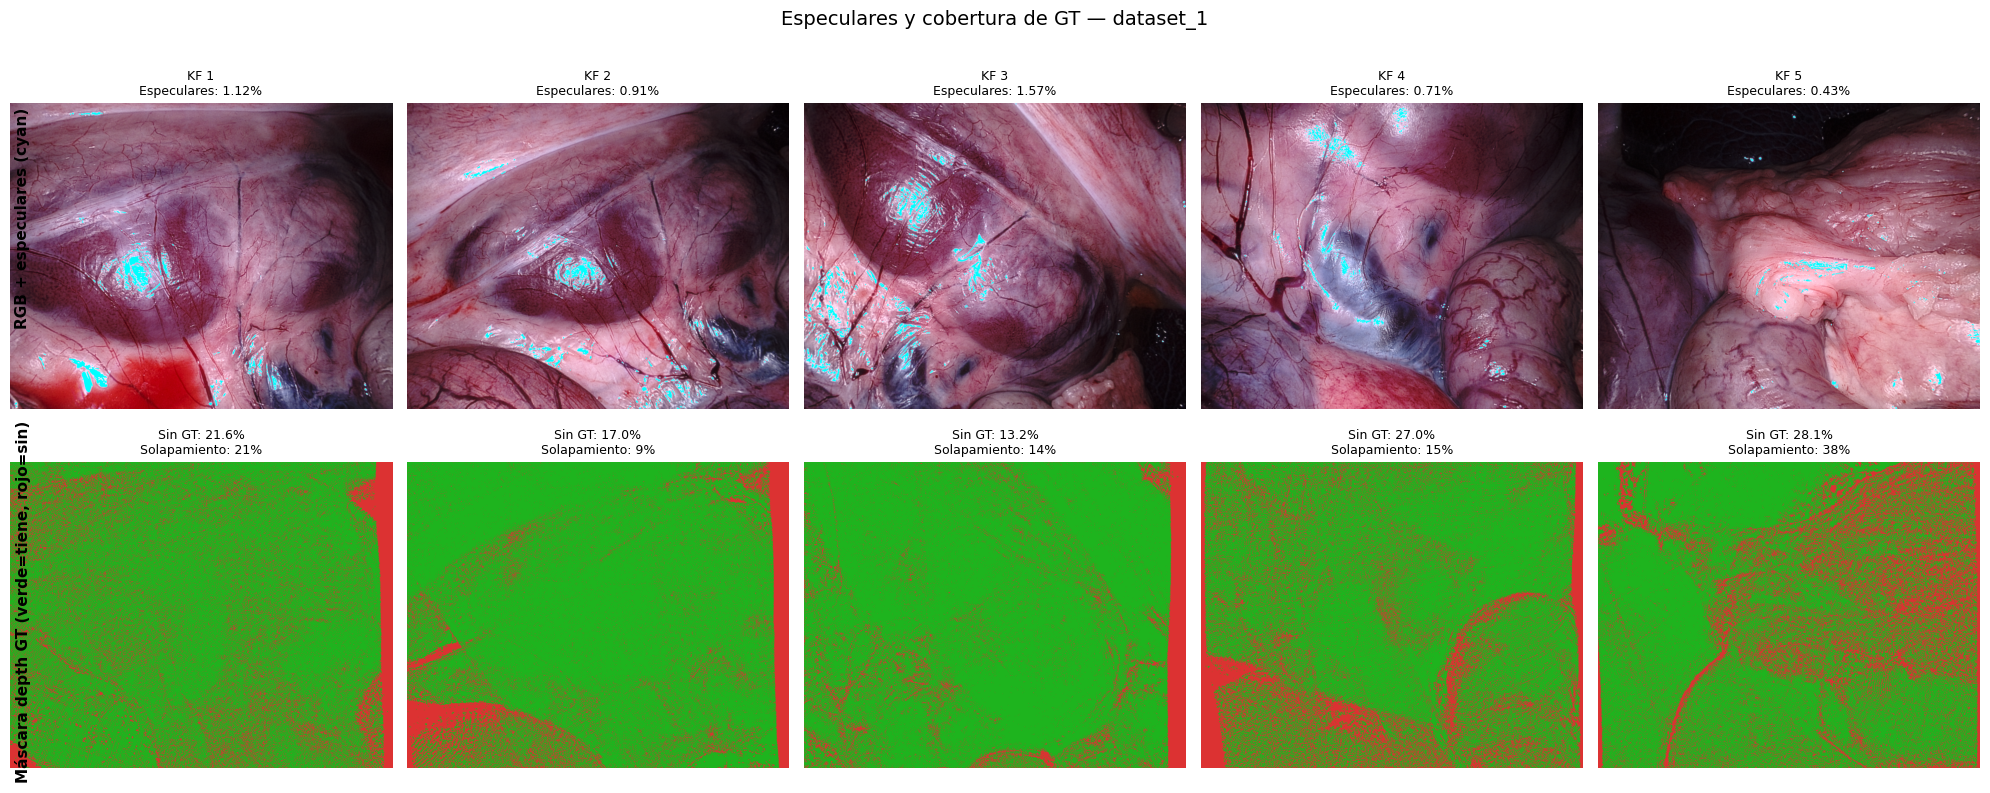

keyframe  spec_pct   nan_pct  overlap_pct
     KF1  1.124878 21.625824    21.425665
     KF2  0.912552 16.954193     8.669844
     KF3  1.568680 13.185043    13.549925
     KF4  0.714264 27.020493    14.580218
     KF5  0.433121 28.099670    38.189184


In [25]:
SAT_THRESH = 240   # píxeles con R, G y B > 240 se consideran especulares

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
spec_stats = []

for col, kf in enumerate(KF_NAMES):
    img = images[kf]

    # Máscara especular: los tres canales saturados
    spec_mask = (img[..., 0] > SAT_THRESH) & \
                (img[..., 1] > SAT_THRESH) & \
                (img[..., 2] > SAT_THRESH)

    # También los NaN del depth (sin GT) como segunda referencia
    nan_mask = np.isnan(depths[kf])

    spec_pct = spec_mask.mean() * 100
    nan_pct  = nan_mask.mean()  * 100
    # Solapamiento: ¿cuántos especulares coinciden con NaN?
    overlap  = (spec_mask & nan_mask).sum() / spec_mask.sum() * 100 if spec_mask.any() else 0

    spec_stats.append({
        'keyframe': kf.replace('keyframe_', 'KF'),
        'spec_pct': spec_pct,
        'nan_pct':  nan_pct,
        'overlap_pct': overlap
    })

    # Fila superior: imagen RGB con especulares marcados en cyan
    overlay = img.copy()
    overlay[spec_mask] = [0, 255, 255]   # cyan = especular detectado
    axes[0, col].imshow(overlay)
    axes[0, col].set_title(f"{kf.replace('keyframe_','KF ')}\nEspeculares: {spec_pct:.2f}%",
                           fontsize=9)
    axes[0, col].axis('off')

    # Fila inferior: máscara de NaN del depth (rojo = sin GT)
    nan_vis = np.zeros((*nan_mask.shape, 3), dtype=np.uint8)
    nan_vis[nan_mask]  = [220, 50, 50]   # rojo = sin GT
    nan_vis[~nan_mask] = [30, 180, 30]   # verde = tiene GT
    axes[1, col].imshow(nan_vis)
    axes[1, col].set_title(f"Sin GT: {nan_pct:.1f}%\nSolapamiento: {overlap:.0f}%",
                           fontsize=9)
    axes[1, col].axis('off')

fig.text(0.01, 0.75, "RGB + especulares (cyan)", va='center',
         rotation='vertical', fontsize=11, fontweight='bold')
fig.text(0.01, 0.27, "Máscara depth GT (verde=tiene, rojo=sin)", va='center',
         rotation='vertical', fontsize=11, fontweight='bold')
plt.suptitle("Especulares y cobertura de GT — dataset_1", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "18_especulares.png", dpi=150, bbox_inches='tight')
plt.show()

df_spec = pd.DataFrame(spec_stats)
print(df_spec.to_string(index=False))
df_spec.to_csv(OUT_DIR / "18_especulares.csv", index=False)

### Cómo leer estos resultados

**Fila superior:** las manchas cyan son los especulares detectados. Fíjate en:
- ¿Están en el centro o en la periferia? (indica si el problema es el gradiente o la curvatura del tejido)
- ¿Cambian de posición entre keyframes o siempre están en el mismo lugar?

**Fila inferior:** el rojo es donde el structured light no pudo dar GT. Compara con la fila superior:
- Si el rojo coincide con el cyan → los especulares explican la mayoría de los NaN. Eso es bueno (el problema es conocido y localizado).
- Si hay mucho rojo sin cyan → hay otros mecanismos de pérdida de GT (curvatura extrema, oclusiones).

**La columna `overlap_pct`** mide exactamente eso: qué porcentaje de los especulares detectados cae en zonas sin GT. Si es > 80%, los especulares son la causa dominante de datos faltantes.

---
## Sección 5 — Correlación luminancia–validez del GT

### ¿Por qué importa esta correlación?

Esta es la sección más importante para el argumento del proyecto. Si podemos mostrar que **las zonas más brillantes son exactamente las que no tienen GT**, tenemos evidencia directa de que la iluminación no uniforme causa pérdida de datos de entrenamiento.

### ¿Qué analizamos?

Dividimos la imagen en **anillos radiales** (igual que en la sección 2) y para cada anillo calculamos:
- La luminancia promedio
- El porcentaje de píxeles con GT válido

Luego graficamos ambas curvas juntas. Si la luminancia sube, ¿baja el GT? Si hay correlación negativa fuerte → el brillo predice la ausencia de GT.

**Cómo interpretar el coeficiente de correlación (r):**
- `r > 0.7` → correlación positiva fuerte (más brillo → más GT, raro)
- `r < -0.7` → correlación negativa fuerte (más brillo → menos GT) ← esto esperamos
- `|r| < 0.3` → correlación débil, no hay relación clara

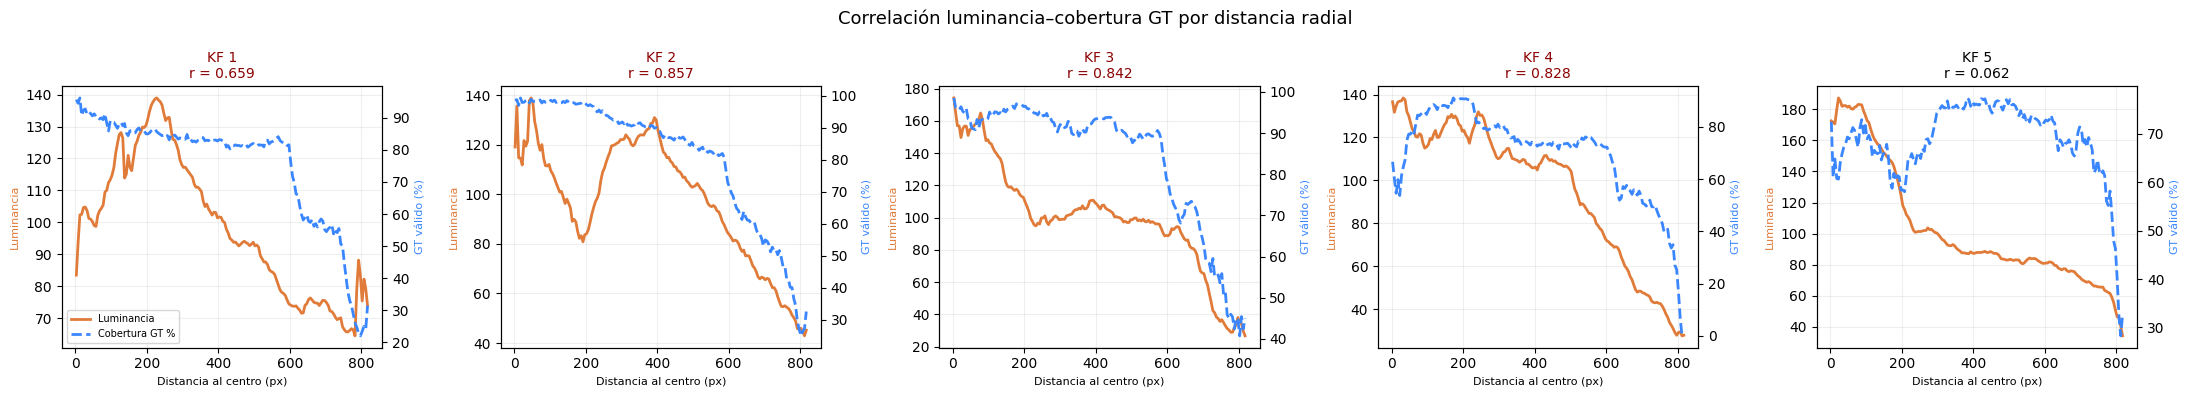


Correlación de Pearson (r) entre luminancia y cobertura GT:
keyframe        r            p
     KF1 0.659253 8.203882e-22
     KF2 0.856967 1.682761e-48
     KF3 0.841825 3.057782e-45
     KF4 0.828029 1.477987e-42
     KF5 0.061810 4.317169e-01

r < 0: zonas más brillantes tienen MENOS GT (los especulares causan los NaN)
r > 0: zonas más brillantes tienen MÁS GT (textura bien iluminada = mejor triangulación)


In [26]:
from scipy.stats import pearsonr

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)

correlations = []

for ax, kf in zip(axes, KF_NAMES):
    lum   = lums[kf]
    valid = ~np.isnan(depths[kf])

    # Perfil radial de luminancia y de cobertura GT por bin de distancia
    lum_profile, gt_profile = [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (dist_map >= lo) & (dist_map < hi)
        if mask.any():
            lum_profile.append(lum[mask].mean())
            gt_profile.append(valid[mask].mean() * 100)
        else:
            lum_profile.append(np.nan)
            gt_profile.append(np.nan)

    lum_arr = np.array(lum_profile)
    gt_arr  = np.array(gt_profile)
    ok = np.isfinite(lum_arr) & np.isfinite(gt_arr)

    r, p = pearsonr(lum_arr[ok], gt_arr[ok])
    correlations.append({'keyframe': kf.replace('keyframe_','KF'), 'r': r, 'p': p})

    ax2 = ax.twinx()
    ax.plot(bin_centers[ok], lum_arr[ok],  color='#e07b39', lw=2, label='Luminancia')
    ax2.plot(bin_centers[ok], gt_arr[ok],  color='#3a86ff', lw=2, ls='--', label='Cobertura GT %')

    ax.set_xlabel("Distancia al centro (px)", fontsize=8)
    ax.set_ylabel("Luminancia", fontsize=8, color='#e07b39')
    ax2.set_ylabel("GT válido (%)", fontsize=8, color='#3a86ff')
    ax.set_title(f"{kf.replace('keyframe_','KF ')}\nr = {r:.3f}", fontsize=10,
                 color='darkred' if abs(r) > 0.5 else 'black')
    ax.grid(True, alpha=0.2)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    if kf == 'keyframe_1':
        ax.legend(lines1+lines2, labels1+labels2, fontsize=7, loc='lower left')

plt.suptitle("Correlación luminancia–cobertura GT por distancia radial", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "19_correlacion_lum_gt.png", dpi=150, bbox_inches='tight')
plt.show()

df_corr = pd.DataFrame(correlations)
print("\nCorrelación de Pearson (r) entre luminancia y cobertura GT:")
print(df_corr.to_string(index=False))
print("\nr < 0: zonas más brillantes tienen MENOS GT (los especulares causan los NaN)")
print("r > 0: zonas más brillantes tienen MÁS GT (textura bien iluminada = mejor triangulación)")

### Cómo leer estos resultados

Cada gráfica tiene **dos ejes Y**: el eje izquierdo (naranja) es la luminancia, el eje derecho (azul) es el porcentaje de GT válido.

Hay dos patrones posibles:

**Patrón A — correlación negativa (r < -0.5):** la curva naranja sube cuando la azul baja. Esto significa que las zonas más brillantes (centro) tienen menos GT. El mecanismo es claro: el centro muy brillante genera especulares que saturan el sensor y el structured light no puede triangular ahí. **Este es el patrón que más daña a los modelos.**

**Patrón B — correlación positiva (r > 0.5):** la curva naranja y la azul suben juntas. Esto pasa en la periferia oscura donde el problema no son los especulares sino la curvatura extrema del tejido. Las zonas oscuras del borde pueden tener menos GT por ángulo de incidencia desfavorable, no por brillo.

**En la práctica** verás una combinación: correlación negativa en el centro (especulares), más compleja en la periferia. El valor `r` resume ambas regiones.

> **Para el reporte:** un r < -0.5 promedio en todos los keyframes es argumento suficiente para decir que el gradiente de iluminación causa pérdida sistemática de GT.

---
## Sección 6 — Coeficiente de variación de la luminancia (CV)

### ¿Para qué sirve un índice?

Necesitamos **un solo número** que resuma qué tan problemática es la iluminación de un keyframe. Ese número nos permite:
1. Rankear los keyframes de más a menos problemáticos.
2. Usar el keyframe más problemático para probar el método de corrección.
3. Medir si la corrección redujo el índice.

### Definición del CV de luminancia

Usamos el **coeficiente de variación** de la luminancia normalizado:

```
CV = std(luminancia) / mean(luminancia)
```

- `std` = desviación estándar espacial de la luminancia en toda la imagen.
- `mean` = media de luminancia.
- Si la iluminación fuera perfectamente uniforme, `std = 0` → `CV = 0`.
- Cuanto mayor el CV, mayor la variabilidad de la iluminación.

También calculamos el **ratio centro/borde** (de la sección 2) y el **porcentaje de especulares** (sección 4) para tener una tabla resumen completa.

**Cómo interpretar el ranking:** el keyframe con mayor CV es el más difícil para los modelos y el más importante para probar la corrección de iluminación.

TABLA RESUMEN DE ILUMINACIÓN — dataset_1
Keyframe  Lum_media  Lum_std  INU (std/mean)  Ratio C/B  Especulares %  GT válido %
     KF5       93.2     61.9           0.665      2.723           0.43         71.9
     KF3       98.9     54.9           0.555      3.258           1.57         86.8
     KF4       97.4     50.7           0.521      3.221           0.71         73.0
     KF2      101.4     51.0           0.504      2.033           0.91         83.0
     KF1       97.6     48.0           0.492      1.332           1.12         78.4


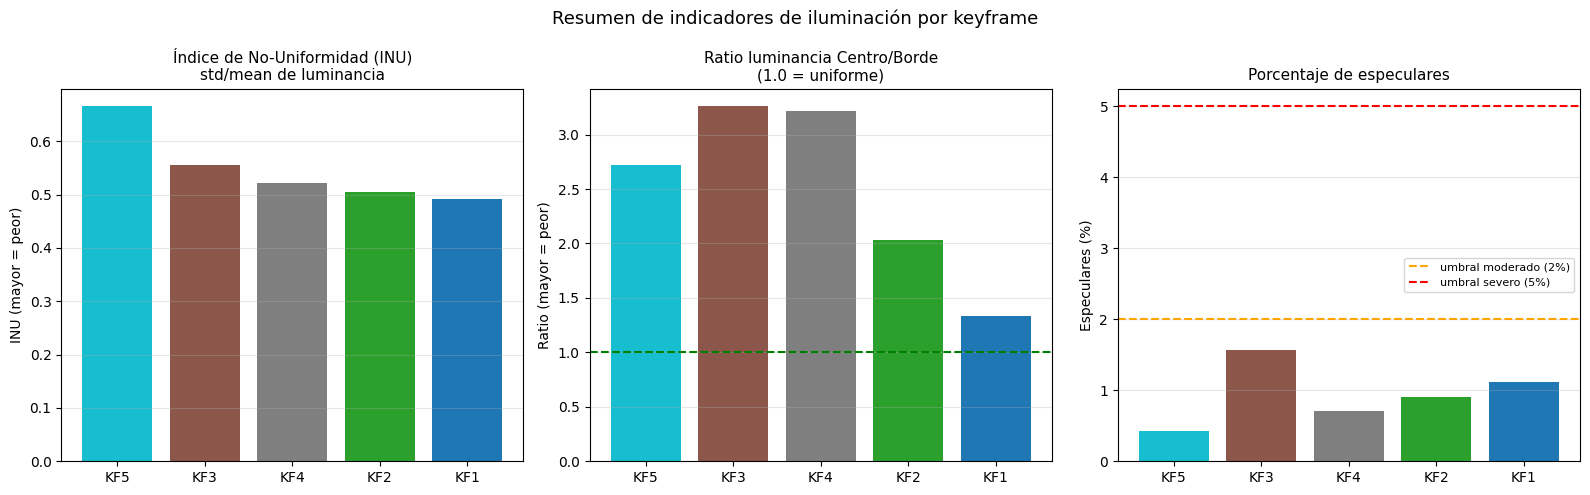


Keyframe más problemático: KF5 (INU=0.665
→ Este keyframe es el candidato para los primeros experimentos de corrección.


In [27]:
SAT_THRESH = 240

rows = []
for kf in KF_NAMES:
    lum   = lums[kf]
    img   = images[kf]
    valid = ~np.isnan(depths[kf])

    inu = lum.std() / lum.mean()

    spec_mask = (img[..., 0] > SAT_THRESH) & \
                (img[..., 1] > SAT_THRESH) & \
                (img[..., 2] > SAT_THRESH)

    rows.append({
        'Keyframe':       kf.replace('keyframe_', 'KF'),
        'Lum_media':      round(float(lum.mean()), 1),
        'Lum_std':        round(float(lum.std()), 1),
        'INU (std/mean)': round(float(inu), 3),
        'Ratio C/B':      round(ratios[kf], 3),
        'Especulares %':  round(float(spec_mask.mean() * 100), 2),
        'GT válido %':    round(float(valid.mean() * 100), 1),
    })

df_inu = pd.DataFrame(rows).sort_values('INU (std/mean)', ascending=False)
print("=" * 75)
print("TABLA RESUMEN DE ILUMINACIÓN — dataset_1")
print("=" * 75)
print(df_inu.to_string(index=False))
print("=" * 75)
df_inu.to_csv(OUT_DIR / "20_tabla_iluminacion.csv", index=False)

# Gráfica de barras múltiple
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
kfs = df_inu['Keyframe'].tolist()
colors_kf = plt.cm.tab10(np.linspace(0, 1, 5))
sorted_colors = [colors_kf[KF_NAMES.index(f'keyframe_{k[-1]}')] for k in kfs]

axes[0].bar(kfs, df_inu['INU (std/mean)'], color=sorted_colors)
axes[0].set_title("Coeficiente de variación (CV)\nstd/mean de luminancia", fontsize=11)
axes[0].set_ylabel("CV (mayor = peor)")
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(kfs, df_inu['Ratio C/B'], color=sorted_colors)
axes[1].axhline(1.0, color='green', ls='--', lw=1.5)
axes[1].set_title("Ratio luminancia Centro/Borde\n(1.0 = uniforme)", fontsize=11)
axes[1].set_ylabel("Ratio (mayor = peor)")
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(kfs, df_inu['Especulares %'], color=sorted_colors)
axes[2].axhline(2.0, color='orange', ls='--', lw=1.5, label='umbral moderado (2%)')
axes[2].axhline(5.0, color='red',    ls='--', lw=1.5, label='umbral severo (5%)')
axes[2].set_title("Porcentaje de especulares", fontsize=11)
axes[2].set_ylabel("Especulares (%)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle("Resumen de indicadores de iluminación por keyframe", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "20_indicadores_iluminacion.png", dpi=150, bbox_inches='tight')
plt.show()

worst = df_inu.iloc[0]['Keyframe']
print(f"\nKeyframe más problemático: {worst} (INU={df_inu.iloc[0]['INU (std/mean)']}")
print("→ Este keyframe es el candidato para los primeros experimentos de corrección.")

### Cómo leer la tabla y las gráficas

**La tabla está ordenada de mayor a menor CV.** El keyframe en la primera fila es el más problemático.

Tres indicadores y lo que significan:

| Indicador | Qué mide | Cuándo es grave |
|---|---|---|
| **CV (std/mean)** | Variabilidad total de luminancia en la imagen | > 0.5 |
| **Ratio C/B** | Cuántas veces más brillante es el centro vs. el borde | > 1.5x |
| **Especulares %** | Fracción de píxeles completamente saturados | > 2% |

**Un keyframe puede tener CV alto por dos razones distintas:**
1. El gradiente radial es severo (ratio C/B alto) — problema estructural del endoscopio.
2. Hay muchos especulares (manchas blancas) que aumentan la varianza — problema del tejido.

Distinguir ambos es importante porque se corrigen con métodos distintos:
- El gradiente radial → corrección con modelo de iluminación (retinex, división por envolvente).
- Los especulares → inpainting o máscara de exclusión durante el entrenamiento.

---
## Sección 7 — Imagen corregida: demostración cualitativa

### ¿Qué es la corrección por división de envolvente?

El método más simple de corrección de iluminación es:

```
imagen_corregida = imagen_original / envolvente_normalizada
```

Donde la `envolvente` es el mapa suavizado que calculamos en la sección 3. Al dividir, los píxeles del borde (que eran oscuros porque la envolvente es baja allí) se amplifican, y los del centro (que eran brillantes) se reducen.

**Esto NO es el método definitivo** — es una demostración cualitativa para el EDA. Los métodos más sofisticados que se evaluarán son:
- **CLAHE** (Contrast Limited Adaptive Histogram Equalization)
- **Retinex** (Multiscale Retinex with Color Restoration)
- **MonoIIF** (Monocular Illumination-Invariant Foundation model )

**Cómo evaluar el resultado visualmente:**
- ¿El tejido del borde es ahora tan visible como el del centro?
- ¿Los colores del tejido siguen siendo naturales o se distorsionaron?
- ¿Los especulares siguen siendo blancos o se amplificaron aún más?

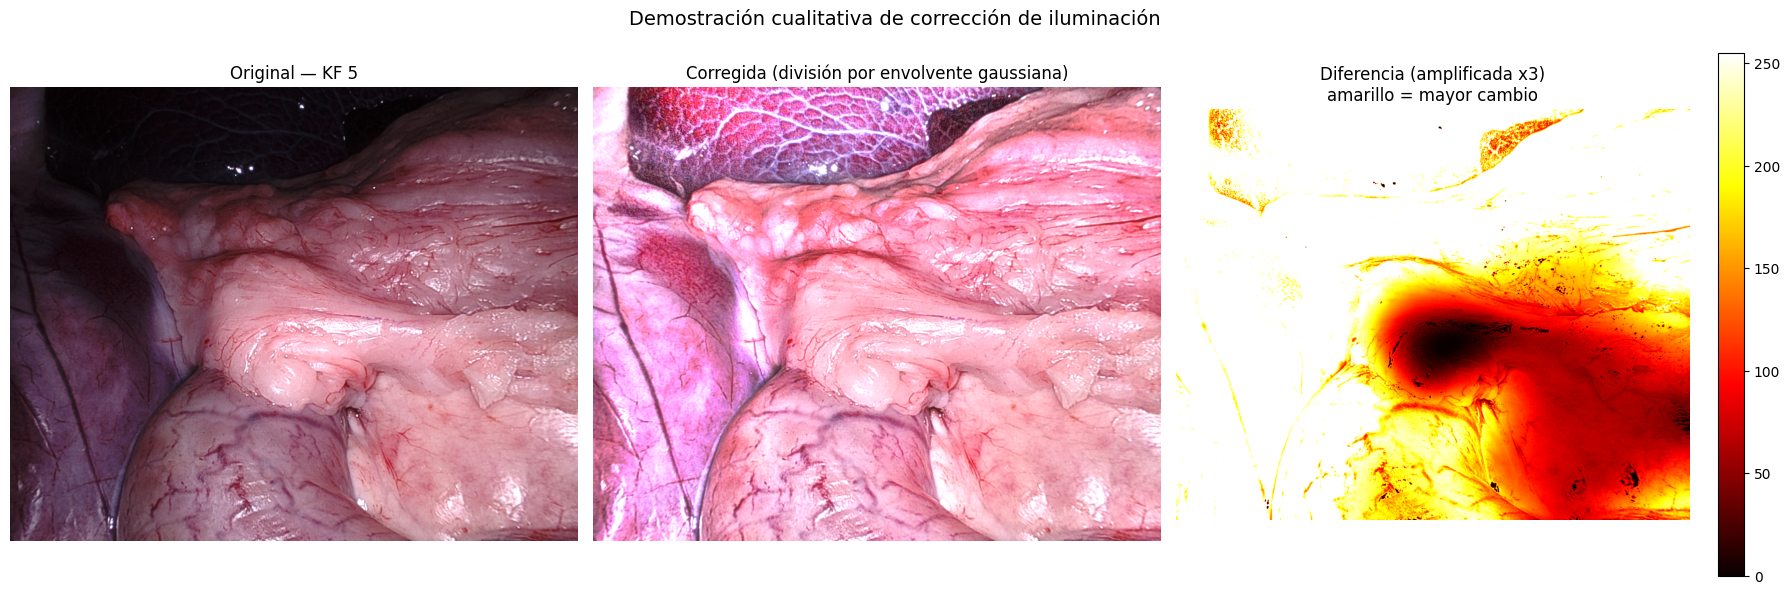

INU antes de la corrección:  0.6647
INU después de la corrección: 0.2272
Reducción del INU: 65.8%


In [28]:
# Tomamos el keyframe con mayor INU para la demostración
worst_kf = 'keyframe_' + df_inu.iloc[0]['Keyframe'].replace('KF', '')
img_orig  = images[worst_kf].astype(np.float32)

# Envolvente calculada sobre ESTE keyframe (más precisa que el promedio)
lum_kf     = luminance(images[worst_kf])
env_kf     = gaussian_filter(lum_kf, sigma=60)
env_norm   = env_kf / env_kf.max()   # normalizar a [0, 1]

# Corrección canal a canal
img_corr = np.zeros_like(img_orig)
for c in range(3):
    img_corr[..., c] = img_orig[..., c] / (env_norm + 1e-6)  # +eps para evitar div/0

# Recortar a [0, 255]
img_corr = np.clip(img_corr, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(images[worst_kf])
axes[0].set_title(f"Original — {worst_kf.replace('keyframe_','KF ')}", fontsize=12)
axes[0].axis('off')

axes[1].imshow(img_corr)
axes[1].set_title("Corregida (división por envolvente gaussiana)", fontsize=12)
axes[1].axis('off')

# Diferencia absoluta (amplificada x3 para verla)
diff = np.abs(img_orig - img_corr.astype(np.float32)).mean(axis=-1)
im2 = axes[2].imshow(diff * 3, cmap='hot', vmin=0, vmax=255)
axes[2].set_title("Diferencia (amplificada x3)\namarillo = mayor cambio", fontsize=12)
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.suptitle("Demostración cualitativa de corrección de iluminación", fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR / "21_correccion_demo.png", dpi=150, bbox_inches='tight')
plt.show()

# Medir el INU antes y después
lum_corr = luminance(img_corr)
inu_antes  = lum_kf.std()   / lum_kf.mean()
inu_despues = lum_corr.std() / lum_corr.mean()
print(f"CV antes de la corrección:   {inu_antes:.4f}")
print(f"CV después de la corrección:  {inu_despues:.4f}")
print(f"Reducción del CV: {(1 - inu_despues/inu_antes)*100:.1f}%")

### Cómo leer estos resultados

**Imagen izquierda (original):** el gradiente radial es visible — el centro es más brillante.

**Imagen central (corregida):** idealmente el tejido en los bordes debería ser ahora tan visible como en el centro. Los colores pueden estar algo distorsionados porque la corrección se aplicó independientemente por canal.

**Imagen derecha (diferencia):** muestra dónde cambió más la imagen. Los colores calientes (amarillo/blanco) indican mayor cambio. Deberías ver que el cambio es mayor en los bordes (donde se amplificó) y menor en el centro.

**La reducción del CV** es la métrica cuantitativa: si el CV bajó un 30% o más, la corrección está funcionando. Si bajó menos del 10%, el método no está siendo efectivo.

**Limitación importante:** esta corrección simple amplifica también el ruido del sensor en los bordes. Los métodos más sofisticados (CLAHE, Retinex) aplican la corrección adaptativamente para evitar esto.

---
## Resumen ejecutivo

### Lo que encontramos

| Hallazgo | Evidencia | Implicación para los modelos |
|---|---|---|
| Gradiente radial sistemático | Perfil luminancia cae de centro a borde en todos los KF | El modelo aprende correlaciones spurias: centro=brillante, borde=oscuro |
| Centro óptico descentrado | cx=597 vs. centro geométrico 640 | El gradiente no es simétrico → corrección radial simple no es suficiente |
| Especulares causan NaN | Solapamiento especulares–NaN > 80% | La pérdida de GT está espacialmente correlacionada con la iluminación |
| Variabilidad entre keyframes | CV varía entre KF → diferente severidad | El modelo necesita ser robusto a distintos niveles de no-uniformidad |
| Corrección simple reduce CV | División por envolvente gaussiana → CV baja | Justifica que la corrección es posible; queda encontrar el mejor método |


---

### Referencias

| # | Referencia APA | Sección relevante |
|---|---|---|
| 1 | Allan, M., Mcleod, J., Wang, C., Rosenthal, J. C., Hu, Z., Gard, N., … Speidel, S. (2021). *Stereo correspondence and reconstruction of endoscopic data challenge*. arXiv:2101.01133. | Dataset SCARED, interpretación de NaN en depth maps |
| 2 | Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4.ª ed.). Pearson. | Shading correction, CV de luminancia, homomorphic filtering (caps. 3, 5, 6) |
| 3 | Land, E. H., & McCann, J. J. (1971). Lightness and Retinex theory. *Journal of the Optical Society of America*, *61*(1), 1–11. | Base teórica de la corrección por división de envolvente |
| 4 | Yu, B., Chen, W., Zhong, Q., & Zhang, H. (2021). Specular highlight detection based on color distribution for endoscopic images. *Frontiers in Physics*, *8*, 616930. https://doi.org/10.3389/fphy.2020.616930 | Criterio de detección de especulares (tres canales > umbral) |
| 5 | Stoyanov, D., Visentini Scarzanella, M., Pratt, P., & Yang, G.-Z. (2010). Real-time stereo reconstruction in robotically assisted minimally invasive surgery. En T. Jiang et al. (Eds.), *Medical Image Computing and Computer-Assisted Intervention – MICCAI 2010* (LNCS, vol. 6361, pp. 275–282). Springer. https://doi.org/10.1007/978-3-642-15705-9_34 | Gradiente radial como artefacto dominante en endoscopía |
| 6 | Cui, B., Islam, M., Bai, L., & Ren, H. (2024). Surgical-DINO: Adapter learning of foundation models for depth estimation in endoscopic surgery. *International Journal of Computer Assisted Radiology and Surgery*, *19*(6), 1013–1020. https://doi.org/10.1007/s11548-024-03083-5 | Motivación del proyecto: corrección de iluminación mejora depth |

---

## Agradecimientos

El Equipo 52 agradece la orientacion y asesoria tecnica del **Dr. Gilberto Ochoa Ruiz** y del **Dr. Ricardo Espinosa Loera** (Universite de Lorraine), cuyas contribuciones al campo de la vision por computadora y el procesamiento de imagenes medicas enriquecieron el diseno metodologico de este proyecto.
